In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าให้กราฟแสดงผลสวยงาม
sns.set_theme(style="whitegrid")

# 1. โหลดข้อมูล (เปลี่ยนชื่อไฟล์ให้ตรงกับที่คุณอัปโหลด)
df_bookings = pd.read_csv('fact_bookings_5000.csv')
df_marketing = pd.read_csv('fact_marketing_spend.csv')

# ดูตัวอย่างข้อมูลเบื้องต้น
print("โหลดข้อมูลสำเร็จ!")
df_bookings.head()

โหลดข้อมูลสำเร็จ!


,booking_id,booking_date,checkin_date,channel_id,Channel Name,rate_code,gross_revenue,Commission Rate,commission_amount,net_revenue,booking_status
0,1,29/10/2025,3/11/2025,1,#REF!,RACK,"4,102.00",#REF!,6.86,"4,547.69",confirmed
1,2,12/10/2025,13/10/2025,2,#REF!,FLASH,"6,418.10",#REF!,919.95,912.01,confirmed
2,3,31/10/2025,2/11/2025,4,#REF!,PROMO20,"3,729.00",#REF!,225.28,"2,891.36",confirmed
3,4,28/11/2025,2/12/2025,3,#REF!,PROMO20,0.00,#REF!,89.68,0.00,cancelled
4,5,12/10/2025,14/10/2025,3,#REF!,RACK,"4,626.90",#REF!,"4,128.34","3,395.31",confirmed


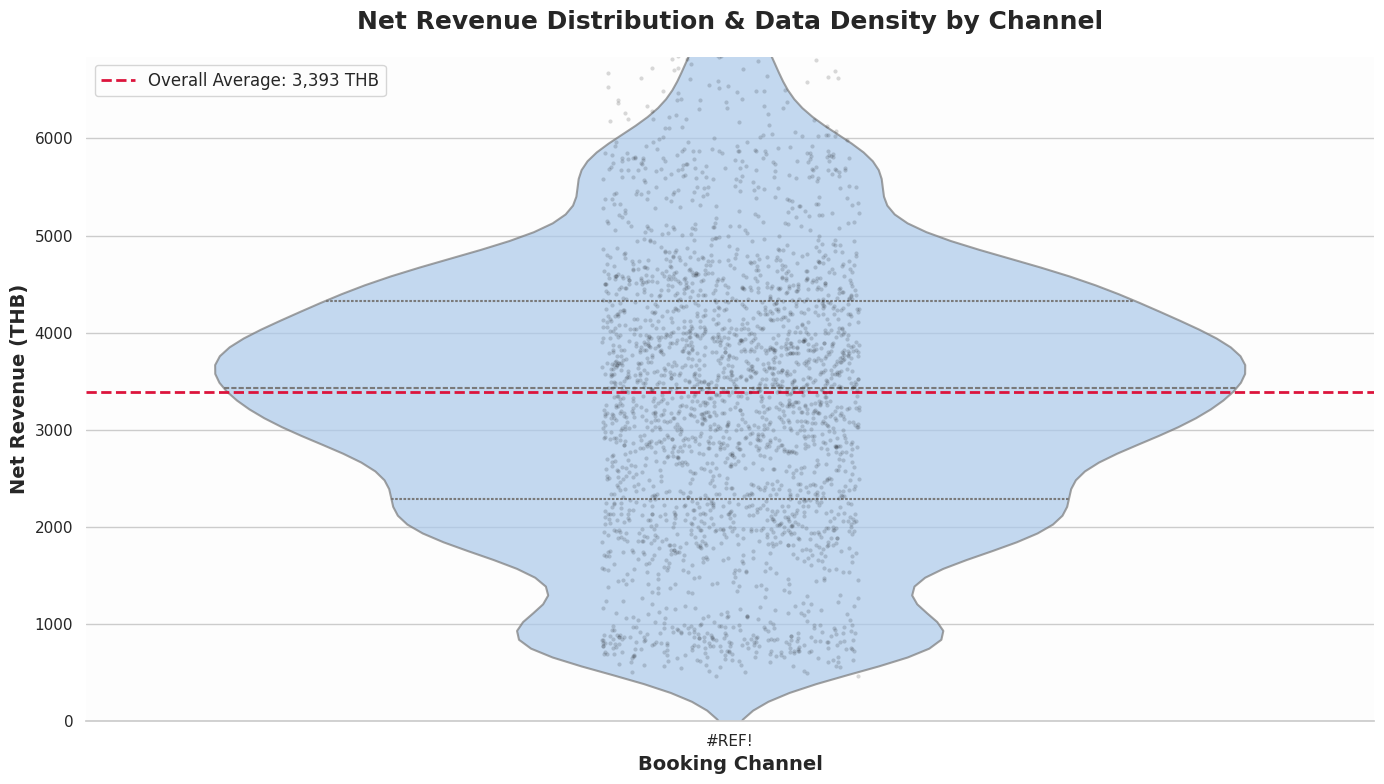

In [ ]:
# 3. วาดกราฟ Violin Plot ผสม Strip Plot เพื่อดูความหนาแน่นและ Outliers
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#fdfdfd"}) # ปรับพื้นหลังให้ดูพรีเมียม

# สร้าง Violin Plot แบบโปร่งแสง
#  [ส่วนที่แก้ไข] เพิ่ม hue='Channel Name' และ legend=False เพื่อแก้ FutureWarning
sns.violinplot(data=df_confirmed, x='Channel Name', y='net_revenue',
               hue='Channel Name', legend=False,
               inner="quartile", palette='pastel', linewidth=1.5, alpha=0.7)

# ซ้อนจุดข้อมูล (Strip Plot) เข้าไปให้ดูซับซ้อนและเห็น Density
sns.stripplot(data=df_confirmed, x='Channel Name', y='net_revenue',
              color='black', alpha=0.15, jitter=True, size=3)

# ใส่เส้นอ้างอิง (Reference Line) เป็นค่าเฉลี่ยของทั้งโรงแรม
overall_mean = df_confirmed['net_revenue'].mean()
plt.axhline(overall_mean, color='crimson', linestyle='--', linewidth=2,
            label=f'Overall Average: {overall_mean:,.0f} THB')

# ตกแต่งตัวอักษรและแกน
plt.title('Net Revenue Distribution & Data Density by Channel', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Net Revenue (THB)', fontsize=14, fontweight='bold')
plt.xlabel('Booking Channel', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')

# ซูมดูข้อมูลหลัก ตัดหางที่กระโดดเกินไปออก
plt.ylim(0, df_confirmed['net_revenue'].quantile(0.98))
sns.despine(left=True) # ลบเส้นขอบกราฟให้ดูโมเดิร์น
plt.tight_layout()

#  [ส่วนที่แก้ไข] เปลี่ยนจาก plt เป็น plt.show() เพื่อปิดการวาดกราฟและลบข้อความ module ขยะ
plt.show()

# 1. ส่วนประกอบของกราฟ
แกน X (แนวนอน): ช่องทางการตลาด (Facebook และ Google)

กราฟแท่งสีฟ้า (ดูตัวเลขแกนซ้าย): Attributed Revenue หรือ "รายได้สุทธิที่เกิดจากช่องทางนั้นๆ" (หน่วยเป็นบาท)

กราฟเส้นสีแดง (ดูตัวเลขแกนขวา): ROAS (Return on Ad Spend) หรือ "ผลตอบแทนจากค่าโฆษณา" (หน่วยเป็นเท่า หรือ Multiplier) บ่งบอกว่าจ่ายเงินค่าโฆษณาไป 1 บาท จะได้ยอดขายกลับมากี่บาท

# 2. สรุปตัวเลขที่น่าสนใจ
Facebook: สร้างรายได้ให้โรงแรมประมาณ 9.18 ล้านบาท โดยมีค่า ROAS อยู่ที่ 310.8 เท่า (จ่ายค่าโฆษณา 1 บาท ได้ยอดขายกลับมา 310.8 บาท)

Google: สร้างรายได้ให้โรงแรมสูงถึง 17.46 ล้านบาท โดยมีค่า ROAS สูงทะลุไปถึง 673.8 เท่า ###  3. บทสรุปสำหรับผู้บริหาร (Executive Summary & Insight)
จากกราฟนี้ เราสามารถสรุปเป็น Insight ทางธุรกิจได้ชัดเจนมากครับ:

Google คือช่องทางที่เป็น "เดอะแบก" อย่างแท้จริง: ชนะ Facebook ขาดลอยทั้งในแง่ของ "ปริมาณรายได้" (เกือบ 2 เท่าของ Facebook) และ "ความคุ้มค่า" (ROAS สูงกว่าเกิน 2 เท่า)

คำแนะนำเชิงกลยุทธ์ (Actionable Insight): หากบริษัทมีงบการตลาดจำกัด กราฟนี้เป็นหลักฐานชั้นดีว่า "ควรโยกงบประมาณ (Shift Budget) ไปลงทุนที่ Google Ads ให้มากขึ้น" เพราะเงินทุกบาทที่จ่ายให้ Google ตอนนี้ สร้างผลตอบแทนกลับมาให้บริษัทได้คุ้มค่ากว่า Facebook อย่างเห็นได้ชัดครับ

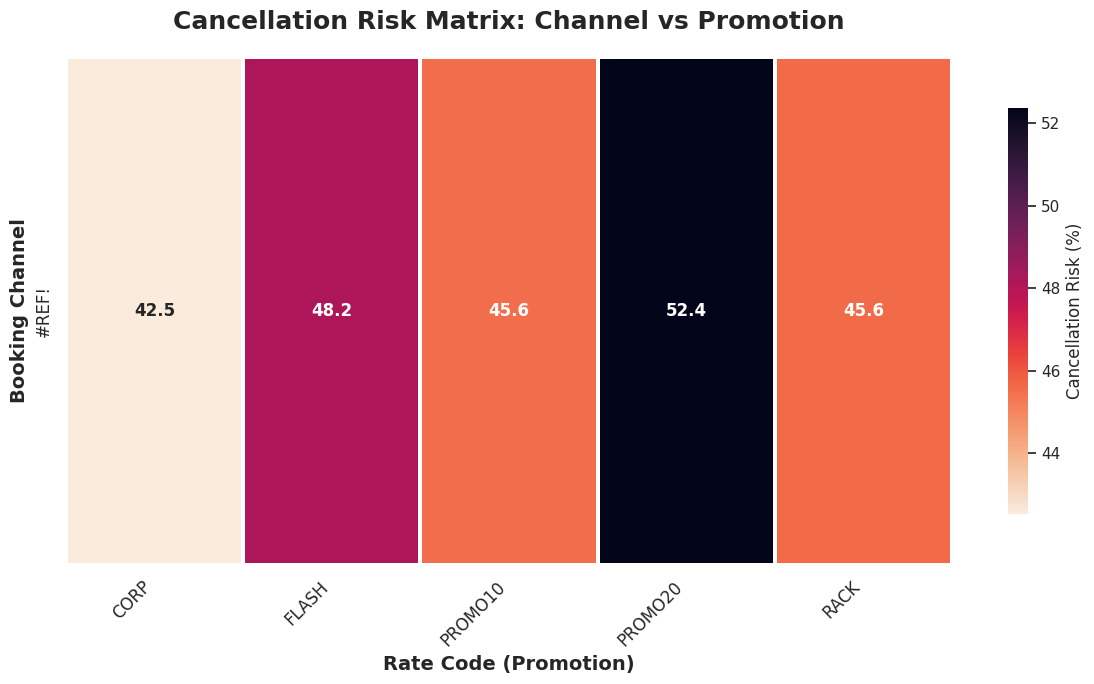

In [ ]:
# 2. วาดกราฟ Heatmap แบบ Executive Matrix

# เตรียมข้อมูลสำหรับ Heatmap: Cancellation Risk Matrix: Channel vs Promotion
# 1. ทำความสะอาดสถานะการจองให้เป็นตัวพิมพ์เล็กทั้งหมด
df_bookings['booking_status_clean'] = df_bookings['booking_status'].astype(str).str.lower()

# 2. นับจำนวนการจองแต่ละสถานะ (confirmed/cancelled) แยกตาม Channel Name และ rate_code
status_by_channel_promo = df_bookings.groupby(['Channel Name', 'rate_code', 'booking_status_clean']).size().unstack(fill_value=0)

# 3. คำนวณอัตราการยกเลิก
# ตรวจสอบว่ามีคอลัมน์ 'cancelled' และ 'confirmed' หรือไม่ หากไม่มีให้ใส่ 0 เพื่อป้องกัน KeyError
if 'cancelled' not in status_by_channel_promo.columns:
    status_by_channel_promo['cancelled'] = 0
if 'confirmed' not in status_by_channel_promo.columns:
    status_by_channel_promo['confirmed'] = 0

status_by_channel_promo['Total_Bookings'] = status_by_channel_promo['confirmed'] + status_by_channel_promo['cancelled']
# ป้องกันหารด้วยศูนย์ ถ้า Total_Bookings เป็น 0 ให้อัตราการยกเลิกเป็น 0
status_by_channel_promo['Cancellation_Rate_Percent'] = (
    status_by_channel_promo['cancelled'] / status_by_channel_promo['Total_Bookings']
) * 100
status_by_channel_promo['Cancellation_Rate_Percent'] = status_by_channel_promo['Cancellation_Rate_Percent'].fillna(0) # แทนที่ NaN ด้วย 0

# 4. สร้าง Pivot Table สำหรับ Heatmap
pivot_status = status_by_channel_promo.pivot_table(
    index='Channel Name',
    columns='rate_code',
    values='Cancellation_Rate_Percent'
)


plt.figure(figsize=(12, 7))

# ใช้ Color Palette แบบไล่สีแดง (ยิ่งแดงยิ่งอันตราย)
cmap = sns.color_palette("rocket_r", as_cmap=True)

ax = sns.heatmap(pivot_status, annot=True, fmt=".1f", cmap=cmap,
                 linewidths=1.5, linecolor='white',
                 cbar_kws={'label': 'Cancellation Risk (%)', 'shrink': 0.8},
                 annot_kws={"size": 12, "weight": "bold"}) # ทำให้ตัวเลขหนาขึ้น

# ตกแต่งตัวอักษร
ax.set_title('Cancellation Risk Matrix: Channel vs Promotion', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Booking Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Rate Code (Promotion)', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

 RACK (Standard Rate): ราคามาตรฐาน หรือ "ราคาเต็ม" หน้าป้ายของโรงแรมที่ยังไม่ได้หักส่วนลดใดๆ ครับ ถือเป็นราคาตั้งต้น

 CORP (Corporate Rate): ราคาองค์กร หรือราคาดีลพิเศษที่โรงแรมทำสัญญากับบริษัทหรือหน่วยงานต่างๆ ไว้ (มักจะถูกกว่าราคาเต็ม และในชุดข้อมูลของคุณระบุว่าราคานี้เป็นแบบไม่ต้องเสียค่าคอมมิชชันด้วยครับ)

 FLASH (Flash Sale): โปรโมชั่นลดราคาแบบกระหน่ำในช่วงเวลาสั้นๆ (เช่น โปร 11.11, Payday Sale, หรือจองนาทีสุดท้าย) เพื่อเร่งกระตุ้นให้ลูกค้าตัดสินใจจองทันที

 PROMO10 (Promotion 10%): โค้ดส่วนลด 10% จากราคาปกติ

 PROMO20 (Promotion 20%): โค้ดส่วนลด 20% จากราคาปกติ (ซึ่งจากข้อมูลของคุณ โปรโมชั่นนี้มีลูกค้านิยมใช้กดจองเยอะที่สุดเลยครับ)

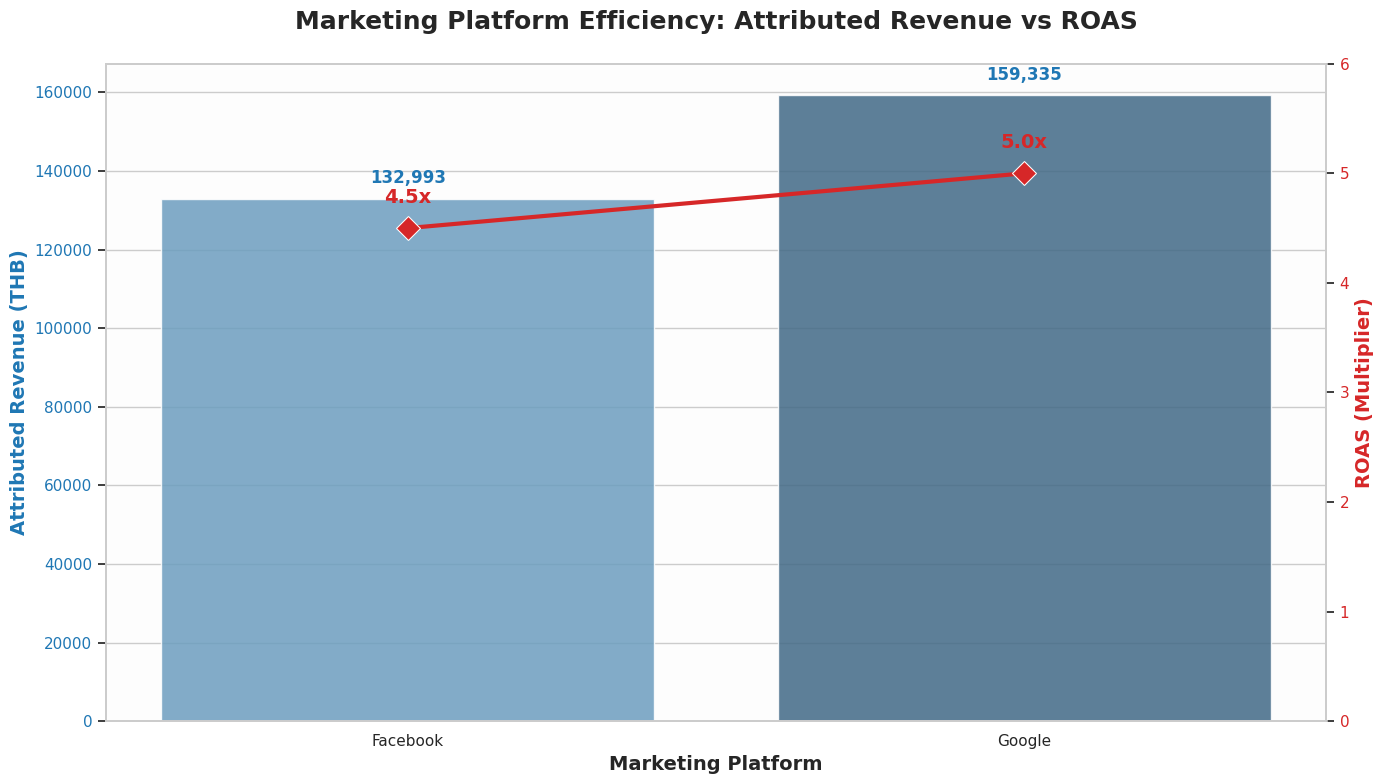

In [ ]:
# 4. วาดกราฟเปรียบเทียบต้นทุนกับรายได้ (Advanced Dual-Axis with Data Labels)
fig, ax1 = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# --- แกนหลัก (ซ้าย): กราฟแท่งแสดงรายได้ ---
bars = sns.barplot(data=marketing_summary, x='platform', y='Attributed_Revenue',
                   hue='platform', palette='Blues_d', ax=ax1, alpha=0.85, legend=False)
ax1.set_ylabel('Attributed Revenue (THB)', fontsize=14, fontweight='bold', color='#1f77b4')
ax1.set_xlabel('Marketing Platform', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# ใส่ตัวเลขกำกับบนกราฟแท่ง
for p in bars.patches:
    bars.annotate(f"{p.get_height():,.0f}",
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, color='#1f77b4',
                  xytext=(0, 8), textcoords='offset points', fontweight='bold')

# --- แกนรอง (ขวา): กราฟเส้นแสดง ROAS ---
ax2 = ax1.twinx()
lines = sns.lineplot(data=marketing_summary, x='platform', y='ROAS (x)',
                     marker='D', markersize=12, color='#d62728', linewidth=3, ax=ax2)
ax2.set_ylabel('ROAS (Multiplier)', fontsize=14, fontweight='bold', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.grid(False) # ปิดเส้น Grid ของแกนรองเพื่อไม่ให้ทับซ้อนกันมั่ว

#  [ส่วนที่แก้ไข] ใส่ตัวเลขกำกับบนกราฟเส้นแบบกำหนดระยะพิกเซล
for x, y in zip(range(len(marketing_summary)), marketing_summary['ROAS (x)']):
    ax2.annotate(f"{y:.1f}x",
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 15), # ดันขึ้น 15 พิกเซลจากจุดเสมอ
                 ha='center', va='bottom',
                 fontsize=14, fontweight='bold', color='#d62728')

#  [ส่วนที่แก้ไข] ขยายเพดานแกน Y ฝั่งขวาขึ้นอีก 20% เพื่อไม่ให้ตัวเลขด้านบนสุดถูกขอบกราฟทับ
ax2.set_ylim(0, marketing_summary['ROAS (x)'].max() * 1.2)

# ตกแต่งกราฟรวม
plt.title('Marketing Platform Efficiency: Attributed Revenue vs ROAS', fontsize=18, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()